# 04 — Predicción de comandas

## Objetivo

La idea de este notebook es desarrollar un primer modelo predictivo para estimar **qué artículos se pedirán y cuántas unidades se venderán en el siguiente periodo de ventas**.

La finalidad dentro de la lógica del TFM es acercar la predicción de demanda a una decisión operativa, es decir, anticipar la preparación necesaria en cocina y traducir las unidades previstas de cada plato a necesidades de ingredientes.

### Restricción fundamental de los datos actuales

La fuente `ventas_silver.parquet` contiene las ventas por artículo agregadas por informes periódicos/semanales. Por tanto, con los datos disponibles actualmente, la predicción rigurosa que puede construirse es:

> **unidades de cada artículo en el siguiente periodo semanal**

No sería correcto afirmar todavía que se predicen platos a nivel diario o por turno, porque esa granularidad no existe en el histórico completo de ventas por artículo con el que trabajamos.

Los 72 tickets PDF sí contienen líneas individuales de producto, pero representan una muestra pequeña del histórico. He pensado que los podríamos utilizar únicamente como posible vía para estudiar coocurrencias entre platos, pero no como fuente principal del modelo de demanda.

---

## Estrategia del notebook

1. Cargar las fuentes Silver y Gold.
2. Auditar la granularidad real de las ventas.
3. Construir un panel `artículo × periodo`.
4. Definir el universo de artículos modelables.
5. Crear variables temporales y de comportamiento histórico.
6. Añadir contexto conocido antes del periodo cuando sea posible.
7. Evitar explícitamente variables con *data leakage*.
8. Comparar *baselines* con modelos supervisados.
9. Validar siempre respetando el orden temporal.
10. Analizar el error global, por artículo y por departamento.
11. Generar la predicción del siguiente periodo.
12. Dejar preparado un punto de integración con las predicciones de clientes, ventas y no-show de los otros modelos del TFM.
13. Explorar de forma opcional los artículos que tienden a pedirse juntos.

## 1. Imports y configuración
 
Los resultados específicos de esta parte se guardan en:

- `results/figures/comandas/`
- `results/predictions/`

La semilla se fija para que los resultados sean reproducibles.

In [ ]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Rutas del repositorio

ROOT = Path.cwd().resolve()

if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

SILVER_DIR = ROOT / 'data' / 'silver' / 'snapshots'
GOLD_DIR = ROOT / 'data' / 'gold'
RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures' / 'comandas'
PREDICTIONS_DIR = RESULTS_DIR / 'predictions'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

from src.tfm_theme import apply_theme

apply_theme()

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 160)

### Parámetros principales

Con estos parámetros podemos cambiar fácilmente el alcance de la predicción.

- Se excluyen invitaciones si la variable existe.
- Los periodos incompletos se excluyen del modelado principal para hacer comparables los targets.
- Definimos un catálogo "modelable" para evitar ajustar un modelo complejo a artículos con poquísimo histórico.
- Los artículos de cola no desaparecen necesariamente del problema, posteriormente los podemos tratar con una regla simple de respaldo.

In [2]:

# Configuración del experimento

DROP_INVITATIONS = True          # Eliminamos de las ventas los artículos marcados como invitación (no se facturan, no generan ingresos).
DROP_INCOMPLETE_PERIODS = True   # Eliminamos posibles informes con menos de 7 días de datos.

MIN_POSITIVE_PERIODS = 8         # Mínimo número de semanas con ventas positivas para que un artículo se considere válido.
MIN_TOTAL_UNITS = 20             # Mínimo número de unidades vendidas en total para que un artículo se considere válido.

LAGS = [1, 2, 3, 4]              # Número de semanas anteriores que se consideran para generar variables lags de ventas y clientes.
ROLLING_WINDOWS = [2, 4, 8]      

N_TEST_PERIODS = 6              # Número de semanas que reservamos para test
N_CV_SPLITS = 4                 # Número de splits para cross-validation
CV_TEST_PERIODS = 4             # Número de semanas que reservamos para test en cada split de cross-validation

TOP_K = 20

INCLUDE_WEATHER = False         # Si True, incluimos variables meteorológicas históricas (en el futuro podríamos añadir predicciones meteorológicas).

INCLUDE_KNOWN_CALENDAR_CONTEXT = True   # Si True, añadimos variables de festivos y eventos.

TEAM_PREDICTIONS_PATH = None  # Posible fichero futuro con salidas del resto de modelos de predicción de Candi, Laura y Ana.
TEAM_PREDICTION_COLUMNS = []  # Ejemplo de columnas: date, pred_clientes, pred_ventas, pred_no_show.

## 2. Carga de datos

La fuente principal es `ventas_silver.parquet`.

Cargamos además:

- `articulos_silver.parquet`: metadatos del artículo.
- `departamentos_silver.parquet`: nombre del departamento.
- `menu_silver.parquet`: referencia auxiliar para identificar artículos presentes en la carta exportada.
- `tabla_maestra_diaria.parquet`: contexto diario ya integrado durante el EDA.
- `festivos_silver.parquet` y `eventos_silver.parquet`: contexto conocido de calendario.

In [3]:
ventas = pd.read_parquet(SILVER_DIR / 'ventas_silver.parquet')
articulos = pd.read_parquet(SILVER_DIR / 'articulos_silver.parquet')
departamentos = pd.read_parquet(SILVER_DIR / 'departamentos_silver.parquet')
menu = pd.read_parquet(SILVER_DIR / 'menu_silver.parquet')
gold_daily = pd.read_parquet(GOLD_DIR / 'tabla_maestra_diaria.parquet')

festivos = pd.read_parquet(SILVER_DIR / 'festivos_silver.parquet')
eventos = pd.read_parquet(SILVER_DIR / 'eventos_silver.parquet')

print('ventas:', ventas.shape)
print('articulos:', articulos.shape)
print('departamentos:', departamentos.shape)
print('menu:', menu.shape)
print('gold_daily:', gold_daily.shape)

display(ventas.head())

ventas: (5532, 14)
articulos: (405, 4)
departamentos: (23, 3)
menu: (405, 3)
gold_daily: (242, 34)


,source_file,report_start,report_end,report_generated_on,terminal_start,terminal_end,turn,department_code,department_name,article_code,article_name,units,amount,es_invitacion
0,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,1901,EMPANADILLA CRIOLLA,32.0,128.00000,False
1,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2031,ROSSINI,19.0,129.54542,False
2,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2239,BOMBONES DE WAGYU Y FOIE,1.0,7.27273,False
3,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2303,BOCATIN DE CALAMARES,19.0,122.63640,False
4,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2306,PAN BAO DE COCHINITA PIBIL,2.0,11.81818,False


## 3. Auditoría de la fuente de ventas

Antes de hacer el modelo comprobamos:

- intervalo temporal de cada informe;
- duración del periodo;
- número de artículos observados;
- unidades e importe;
- posibles unidades negativas;
- invitaciones;
- cobertura temporal.

Este paso es importante porque el target no debe construirse suponiendo una granularidad que los datos no tienen!

In [4]:
sales = ventas.copy()

sales['report_start'] = pd.to_datetime(sales['report_start'], errors='coerce')
sales['report_end'] = pd.to_datetime(sales['report_end'], errors='coerce')
sales['units'] = pd.to_numeric(sales['units'], errors='coerce')
sales['amount'] = pd.to_numeric(sales['amount'], errors='coerce')

sales['period_days'] = (
    sales['report_end'] - sales['report_start']
).dt.days + 1

period_audit = (
    sales.groupby(['report_start', 'report_end'], as_index=False)
    .agg(
        period_days=('period_days', 'first'),
        n_articles=('article_code', 'nunique'),
        total_units=('units', 'sum'),
        total_amount=('amount', 'sum'),
    )
    .sort_values('report_start')
    .reset_index(drop=True)
)

print(f'Número de periodos: {len(period_audit)}')
print(
    'Cobertura:',
    period_audit['report_start'].min().date(),
    '→',
    period_audit['report_end'].max().date(),
)
print('\nDuración de los periodos:')
display(period_audit['period_days'].value_counts().sort_index().rename('n_periodos'))

negative_units = sales.loc[sales['units'] < 0]

print(f'\nFilas con unidades negativas: {len(negative_units)}')

if not negative_units.empty:
    display(
        negative_units[
            [
                'report_start',
                'report_end',
                'article_code',
                'article_name',
                'units',
                'amount',
            ]
        ].head(20)
    )

if 'es_invitacion' in sales.columns:
    print('\nInvitaciones:')
    display(sales['es_invitacion'].value_counts(dropna=False))

display(period_audit.head(10))

Número de periodos: 41
Cobertura: 2025-10-01 → 2026-07-09

Duración de los periodos:


period_days
4     1
5     1
7    39
Name: n_periodos, dtype: int64


Filas con unidades negativas: 0

Invitaciones:


es_invitacion
False    5506
True       26
Name: count, dtype: int64

,report_start,report_end,period_days,n_articles,total_units,total_amount
0,2025-10-01,2025-10-05,5,125,1919.0,10803.93642
1,2025-10-06,2025-10-12,7,142,2523.0,15045.95446
2,2025-10-13,2025-10-19,7,129,1976.0,15082.97273
3,2025-10-20,2025-10-26,7,134,2279.0,13728.26360
4,2025-10-27,2025-11-02,7,129,2124.0,13105.06365
5,2025-11-03,2025-11-09,7,139,2000.0,14923.90904
6,2025-11-10,2025-11-16,7,150,2506.0,15588.33630
7,2025-11-17,2025-11-23,7,144,2370.0,15055.99094
8,2025-11-24,2025-11-30,7,142,2245.0,15114.04551
9,2025-12-01,2025-12-07,7,141,2361.0,14852.63636


### Decisiones de limpieza específicas para el modelado

La capa Silver no la modificamos. Las decisiones siguientes las aplicamos **solo al dataset de modelado**:

1. Se eliminan registros sin artículo, fechas o unidades válidas.
2. Si existen unidades negativas, se excluyen de este primer modelo y se muestran previamente para revisión.
3. Las invitaciones se excluyen del target si `DROP_INVITATIONS=True`.
4. Los periodos con menos de 7 días se pueden excluir para evitar comparar una semana completa con un periodo parcial.

La decisión sobre unidades negativas puede revisarse si se confirma que representan devoluciones y se desea modelarlas explícitamente.

In [5]:
model_sales = sales.dropna(
    subset=[
        'report_start',
        'report_end',
        'article_code',
        'units',
    ]
).copy()

model_sales = model_sales.loc[model_sales['units'] >= 0].copy()

if DROP_INVITATIONS and 'es_invitacion' in model_sales.columns:
    model_sales = model_sales.loc[
        ~model_sales['es_invitacion'].fillna(False)
    ].copy()

if DROP_INCOMPLETE_PERIODS:
    complete_periods = period_audit.loc[
        period_audit['period_days'] == 7,
        ['report_start', 'report_end']
    ]

    model_sales = model_sales.merge(
        complete_periods,
        on=['report_start', 'report_end'],
        how='inner',
    )

print('Filas de ventas para modelado:', len(model_sales))
print('Periodos:', model_sales['report_start'].nunique())
print('Artículos:', model_sales['article_code'].nunique())

Filas de ventas para modelado: 5291
Periodos: 39
Artículos: 251


## 4. Universo de artículos

Un problema importante que tenemos es la cola larga, hay artículos muy frecuentes y otros con muy pocas observaciones.

Ajustar un modelo independiente para cada plato sería peligroso porque solo hay unas decenas de periodos. Creo que es mejor que hagamos un **modelo global**, o sea, todas las observaciones artículo-periodo alimentan el mismo modelo.

Para que el modelo no esté dominado por artículos casi inexistentes, definimos un catálogo principal con dos condiciones:

- número mínimo de periodos con venta;
- número mínimo de unidades totales.

Los umbrales son configurables y se calcula qué porcentaje de unidades e ingresos cubre el catálogo seleccionado.

In [6]:
article_summary = (
    model_sales.groupby(
        ['article_code', 'article_name', 'department_code'],
        as_index=False,
    )
    .agg(
        positive_periods=('report_start', 'nunique'),
        total_units=('units', 'sum'),
        total_amount=('amount', 'sum'),
    )
)

article_summary['is_core'] = (
    (article_summary['positive_periods'] >= MIN_POSITIVE_PERIODS)
    & (article_summary['total_units'] >= MIN_TOTAL_UNITS)
)

coverage_units = (
    article_summary.loc[article_summary['is_core'], 'total_units'].sum()
    / article_summary['total_units'].sum()
)

coverage_amount = (
    article_summary.loc[article_summary['is_core'], 'total_amount'].sum()
    / article_summary['total_amount'].sum()
)

print('Artículos totales:', len(article_summary))
print('Artículos modelables:', int(article_summary['is_core'].sum()))
print(f'Cobertura de unidades: {coverage_units:.1%}')
print(f'Cobertura de facturación: {coverage_amount:.1%}')

display(
    article_summary.sort_values('total_units', ascending=False).head(30)
)

Artículos totales: 263
Artículos modelables: 164
Cobertura de unidades: 98.9%
Cobertura de facturación: 98.1%


,article_code,article_name,department_code,positive_periods,total_units,total_amount,is_core
19,96,RACIÓN DE PAN,15,39,14908.0,24370.36505,True
31,1637,COPA DE VICTORIA,5,39,5119.0,22325.24695,True
34,1690,CAFÉ E INFUSIONES,13,39,4480.0,9217.13893,True
115,2138,SAM DE GAMBAS,28,39,3025.0,14968.18312,True
75,1945,EXTRA CROQUETA DE JAMON,22,39,2781.0,4036.79951,True
185,2309,AGUA 70CL,4,39,2674.0,7260.26747,True
1,2,RAVIOLI DE RABO DE TERNERA,28,39,2378.0,14260.79986,True
35,1691,CERVEZA VICTORIA,5,39,2016.0,5782.10708,True
233,2381,PAN BAO DE CARRILLERA DE CERDO,1,39,1967.0,12157.78296,True
251,30001,MENU DEL DIA,30,37,1845.0,34047.90932,True


In [7]:
core_articles = article_summary.loc[
    article_summary['is_core'],
    'article_code',
].unique()

core_sales = model_sales.loc[
    model_sales['article_code'].isin(core_articles)
].copy()

### Nota sobre "platos" frente a "artículos"

La fuente de ventas tiene artículos de cocina y también otras líneas de venta, como bebidas.

En esta primera versión modelamos el comportamiento de los **artículos commandables**. Después podríamos:

- filtrar la salida por departamentos de cocina;
- construir un catálogo `food_only`;
- o mantener todos los artículos si el objetivo operativo incluye también bebidas.

No eliminamos departamentos automáticamente para no introducir una clasificación arbitraria.

In [8]:
department_summary = (
    core_sales.groupby(
        ['department_code', 'department_name'],
        as_index=False,
    )
    .agg(
        n_articles=('article_code', 'nunique'),
        units=('units', 'sum'),
        amount=('amount', 'sum'),
    )
    .sort_values('amount', ascending=False)
)

display(department_summary)

,department_code,department_name,n_articles,units,amount
2,3,CARTA,29,9094.0,158930.34859
10,14,SUGERENCIAS,20,6235.0,60827.65037
14,28,CLASICOS,7,9334.0,53270.15819
11,15,OTROS,3,15815.0,50619.59210
0,1,TAPAS CALIENTES,8,7575.0,47199.01953
4,5,CERVEZAS,11,10791.0,41761.12296
9,13,POSTRES,13,9050.0,38305.98265
16,30,MENU DEL DIA,1,1845.0,34047.90932
3,4,REFRESCOS,16,9050.0,25816.50414
7,9,TINTOS,15,3289.0,25173.80004


## 5. Construcción del panel artículo × periodo

Los informes contienen normalmente solo los artículos que aparecen en cada periodo.

Para modelar demanda necesitamos representar también los ceros. Si un artículo estuvo activo durante una parte del histórico y no aparece en uno de esos periodos, se interpreta como cero unidades.

Para bajar el riesgo de confundir "no se vendió" con "todavía no existía" o "ya no estaba disponible", solo se completan ceros entre el primer y el último periodo observado de cada artículo.

In [9]:
periods = (
    core_sales[
        ['report_start', 'report_end']
    ]
    .drop_duplicates()
    .sort_values('report_start')
    .reset_index(drop=True)
)

periods['period_id'] = np.arange(len(periods))

sales_agg = (
    core_sales.groupby(
        [
            'report_start',
            'report_end',
            'article_code',
            'article_name',
            'department_code',
            'department_name',
        ],
        as_index=False,
    )
    .agg(
        units=('units', 'sum'),
        amount=('amount', 'sum'),
    )
)

sales_agg = sales_agg.merge(
    periods,
    on=['report_start', 'report_end'],
    how='left',
)

article_meta = (
    sales_agg.sort_values('report_start')
    .groupby('article_code', as_index=False)
    .agg(
        article_name=('article_name', 'last'),
        department_code=('department_code', 'last'),
        department_name=('department_name', 'last'),
        first_period_id=('period_id', 'min'),
        last_period_id=('period_id', 'max'),
    )
)

panel_parts = []

for row in article_meta.itertuples(index=False):
    article_periods = periods.loc[
        periods['period_id'].between(
            row.first_period_id,
            row.last_period_id,
        )
    ].copy()

    article_periods['article_code'] = row.article_code
    article_periods['article_name'] = row.article_name
    article_periods['department_code'] = row.department_code
    article_periods['department_name'] = row.department_name

    panel_parts.append(article_periods)

panel = pd.concat(
    panel_parts,
    ignore_index=True,
)

panel = panel.merge(
    sales_agg[
        [
            'period_id',
            'article_code',
            'units',
            'amount',
        ]
    ],
    on=['period_id', 'article_code'],
    how='left',
)

panel['units'] = panel['units'].fillna(0.0)
panel['amount'] = panel['amount'].fillna(0.0)

panel = panel.sort_values(
    ['article_code', 'period_id']
).reset_index(drop=True)

print('Panel:', panel.shape)
print('Periodos:', panel['period_id'].nunique())
print('Artículos:', panel['article_code'].nunique())
print(f'Proporción de ceros: {(panel["units"] == 0).mean():.1%}')

display(panel.head())

Panel: (5835, 9)
Periodos: 39
Artículos: 160
Proporción de ceros: 16.6%


,report_start,report_end,period_id,article_code,article_name,department_code,department_name,units,amount
0,2025-10-06,2025-10-12,0,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,32.0,198.18195
1,2025-10-13,2025-10-19,1,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,20.0,112.18190
2,2025-10-20,2025-10-26,2,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,28.0,155.81828
3,2025-10-27,2025-11-02,3,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,18.0,107.63643
4,2025-11-03,2025-11-09,4,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,24.0,145.09101


## 6. EDA específico para predicción de comandas

Antes del modelo nos interesa responder:

- Qué artículos concentran la demanda?
- Cuántos ceros hay por artículo?
- Qué artículos tienen una demanda estable?
- Qué departamentos son más predecibles?
- Cuánta persistencia existe entre una semana y la siguiente?

Este EDA complementa el EDA general del proyecto y lo estoy orientado específicamente al target de comandas.

In [10]:
demand_profile = (
    panel.groupby(
        ['article_code', 'article_name', 'department_name'],
        as_index=False,
    )
    .agg(
        mean_units=('units', 'mean'),
        median_units=('units', 'median'),
        std_units=('units', 'std'),
        zero_rate=('units', lambda s: (s == 0).mean()),
        periods=('period_id', 'nunique'),
        total_units=('units', 'sum'),
    )
)

demand_profile['cv'] = (
    demand_profile['std_units']
    / demand_profile['mean_units'].replace(0, np.nan)
)

display(
    demand_profile.sort_values(
        'total_units',
        ascending=False,
    ).head(30)
)

,article_code,article_name,department_name,mean_units,median_units,std_units,zero_rate,periods,total_units,cv
18,96,RACIÓN DE PAN,OTROS,382.256410,372.0,51.435047,0.000000,39,14908.0,0.134556
29,1637,COPA DE VICTORIA,CERVEZAS,131.256410,135.0,28.191748,0.000000,39,5119.0,0.214784
32,1690,CAFÉ E INFUSIONES,POSTRES,114.871795,117.0,20.664207,0.000000,39,4480.0,0.179889
84,2138,SAM DE GAMBAS,CLASICOS,77.564103,81.0,17.985074,0.000000,39,3025.0,0.231874
64,1945,EXTRA CROQUETA DE JAMON,EXTRAS,71.307692,65.0,35.191322,0.000000,39,2781.0,0.493514
125,2309,AGUA 70CL,REFRESCOS,68.564103,71.0,14.035284,0.000000,39,2674.0,0.204703
1,2,RAVIOLI DE RABO DE TERNERA,CLASICOS,60.974359,56.0,16.667787,0.000000,39,2378.0,0.273357
33,1691,CERVEZA VICTORIA,CERVEZAS,51.692308,46.0,22.565873,0.000000,39,2016.0,0.436542
150,2381,PAN BAO DE CARRILLERA DE CERDO,TAPAS CALIENTES,50.435897,50.0,13.798922,0.000000,39,1967.0,0.273593
68,1974,ZAMBURIÑAS A LA BRASA,CARTA,54.371429,54.0,22.352899,0.000000,35,1903.0,0.411115


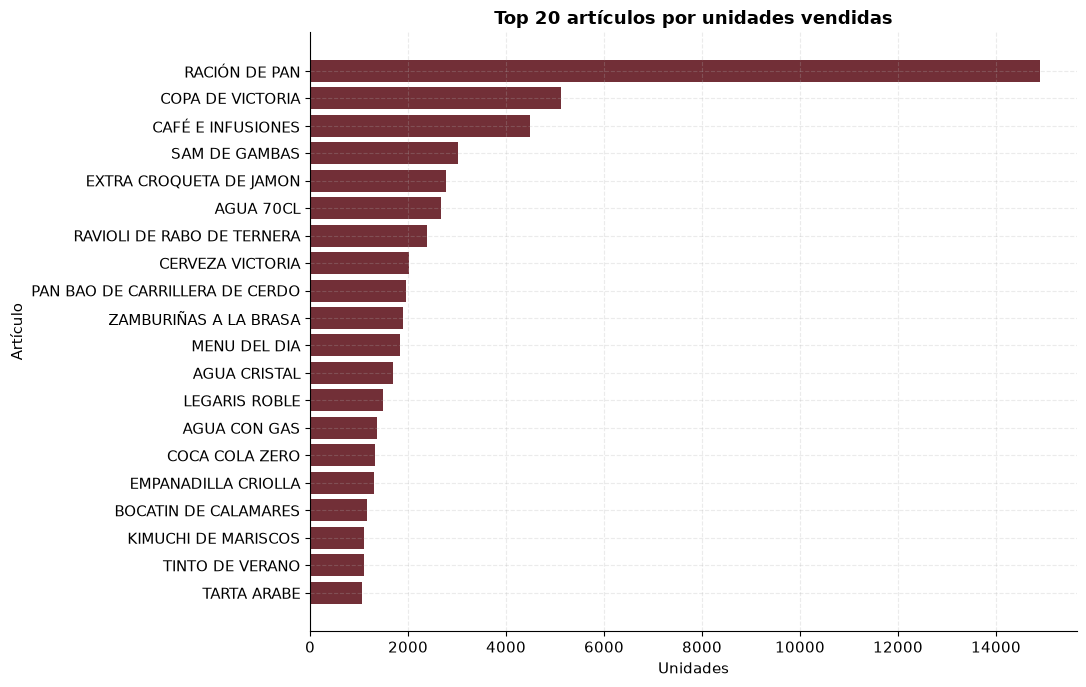

In [11]:
top_articles = (
    demand_profile
    .sort_values('total_units', ascending=False)
    .head(20)
    .sort_values('total_units')
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    top_articles['article_name'],
    top_articles['total_units'],
)

ax.set_title('Top 20 artículos por unidades vendidas')
ax.set_xlabel('Unidades')
ax.set_ylabel('Artículo')

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'top_articulos_unidades.png',
    dpi=300,
    bbox_inches='tight',
)

plt.show()

In [12]:
lag_pairs = panel[
    ['article_code', 'period_id', 'units']
].copy()

lag_pairs['units_lag_1'] = (
    lag_pairs.groupby('article_code')['units']
    .shift(1)
)

lag_corr = lag_pairs[
    ['units', 'units_lag_1']
].corr().iloc[0, 1]

print(
    'Correlación global entre unidades actuales '
    f'y lag de 1 periodo: {lag_corr:.3f}'
)

Correlación global entre unidades actuales y lag de 1 periodo: 0.954


## 7. Feature engineering

Las variables históricas las construimos siempre con:

- `shift(1)`;
- lags de periodos anteriores;
- medias móviles calculadas sobre el pasado;
- estadísticas acumuladas desplazadas.

No utilizamos como predictors:

- `units` del periodo actual;
- `amount` del periodo actual;
- facturación real del periodo;
- tickets reales del periodo;
- reservas finalmente completadas;
- no-show real;
- variables que solo se conocen después del servicio.

In [13]:
def add_demand_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    data = dataframe.copy()

    data = data.sort_values(
        ['article_code', 'period_id']
    ).reset_index(drop=True)

    group = data.groupby(
        'article_code',
        group_keys=False,
    )

    for lag in LAGS:
        data[f'units_lag_{lag}'] = (
            group['units'].shift(lag)
        )

    for window in ROLLING_WINDOWS:
        data[f'units_roll_mean_{window}'] = (
            group['units']
            .transform(
                lambda s: (
                    s.shift(1)
                    .rolling(
                        window=window,
                        min_periods=2,
                    )
                    .mean()
                )
            )
        )

        data[f'units_roll_std_{window}'] = (
            group['units']
            .transform(
                lambda s: (
                    s.shift(1)
                    .rolling(
                        window=window,
                        min_periods=2,
                    )
                    .std()
                )
            )
        )

        data[f'zero_rate_{window}'] = (
            group['units']
            .transform(
                lambda s: (
                    s.shift(1)
                    .eq(0)
                    .rolling(
                        window=window,
                        min_periods=2,
                    )
                    .mean()
                )
            )
        )

    data['historical_mean_units'] = (
        group['units']
        .transform(
            lambda s: (
                s.shift(1)
                .expanding(min_periods=2)
                .mean()
            )
        )
    )

    data['historical_max_units'] = (
        group['units']
        .transform(
            lambda s: (
                s.shift(1)
                .expanding(min_periods=2)
                .max()
            )
        )
    )

    data['trend_1_4'] = (
        data['units_lag_1']
        - data['units_lag_4']
    )

    data['period_days'] = (
        data['report_end']
        - data['report_start']
    ).dt.days + 1

    data['month'] = data['report_start'].dt.month
    data['quarter'] = data['report_start'].dt.quarter
    data['week_of_year'] = (
        data['report_start']
        .dt.isocalendar()
        .week
        .astype(int)
    )

    data['week_sin'] = np.sin(
        2 * np.pi * data['week_of_year'] / 52
    )

    data['week_cos'] = np.cos(
        2 * np.pi * data['week_of_year'] / 52
    )

    return data


model_panel = add_demand_features(panel)

display(model_panel.head(10))

,report_start,report_end,period_id,article_code,article_name,department_code,department_name,units,amount,units_lag_1,units_lag_2,units_lag_3,units_lag_4,units_roll_mean_2,units_roll_std_2,zero_rate_2,units_roll_mean_4,units_roll_std_4,zero_rate_4,units_roll_mean_8,units_roll_std_8,zero_rate_8,historical_mean_units,historical_max_units,trend_1_4,period_days,month,quarter,week_of_year,week_sin,week_cos
0,2025-10-06,2025-10-12,0,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,32.0,198.18195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,10,4,41,-0.970942,0.239316
1,2025-10-13,2025-10-19,1,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,20.0,112.18190,32.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,7,10,4,42,-0.935016,0.354605
2,2025-10-20,2025-10-26,2,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,28.0,155.81828,20.0,32.0,NaN,NaN,26.0,8.485281,0.0,26.000000,8.485281,0.0,26.000000,8.485281,0.0,26.000000,32.0,NaN,7,10,4,43,-0.885456,0.464723
3,2025-10-27,2025-11-02,3,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,18.0,107.63643,28.0,20.0,32.0,NaN,24.0,5.656854,0.0,26.666667,6.110101,0.0,26.666667,6.110101,0.0,26.666667,32.0,NaN,7,10,4,44,-0.822984,0.568065
4,2025-11-03,2025-11-09,4,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,24.0,145.09101,18.0,28.0,20.0,32.0,23.0,7.071068,0.0,24.500000,6.608076,0.0,24.500000,6.608076,0.0,24.500000,32.0,-14.0,7,11,4,45,-0.748511,0.663123
5,2025-11-10,2025-11-16,5,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,26.0,156.00007,24.0,18.0,28.0,20.0,21.0,4.242641,0.0,22.500000,4.434712,0.0,24.400000,5.727128,0.0,24.400000,32.0,4.0,7,11,4,46,-0.663123,0.748511
6,2025-11-17,2025-11-23,6,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,28.0,195.27281,26.0,24.0,18.0,28.0,25.0,1.414214,0.0,24.000000,4.320494,0.0,24.666667,5.163978,0.0,24.666667,32.0,-2.0,7,11,4,47,-0.568065,0.822984
7,2025-11-24,2025-11-30,7,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,23.0,153.81825,28.0,26.0,24.0,18.0,27.0,1.414214,0.0,24.000000,4.320494,0.0,25.142857,4.879500,0.0,25.142857,32.0,10.0,7,11,4,48,-0.464723,0.885456
8,2025-12-01,2025-12-07,8,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,28.0,181.09097,23.0,28.0,26.0,24.0,25.5,3.535534,0.0,25.250000,2.217356,0.0,24.875000,4.580627,0.0,24.875000,32.0,-1.0,7,12,4,49,-0.354605,0.935016
9,2025-12-08,2025-12-14,9,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,32.0,202.90920,28.0,23.0,28.0,26.0,25.5,3.535534,0.0,26.250000,2.362908,0.0,24.375000,3.852179,0.0,25.222222,32.0,2.0,7,12,4,50,-0.239316,0.970942


### 7.1 Contexto semanal conocido

La tabla Gold tiene granularidad diaria. Para cada intervalo de ventas agregamos únicamente variables que tengan sentido predictivo.

#### Variables de calendario/eventos

Se pueden conocer antes del periodo y son adecuadas para un modelo real:

- número de festivos;
- número de días con evento;
- intensidad máxima/media de eventos;
- días de fin de semana.

#### Meteorología

El tiempo histórico puede utilizarse para analizar si nos aporta señal. Sin embargo, en producción el modelo tendría que recibir una previsión meteorológica futura, no el tiempo real del periodo a predecir.

Por eso `INCLUDE_WEATHER=False` por defecto.

In [14]:
gold = gold_daily.copy()

gold['fecha'] = pd.to_datetime(
    gold['fecha'],
    errors='coerce',
)

def aggregate_daily_context_to_periods(
    daily: pd.DataFrame,
    period_table: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for period in period_table.itertuples(index=False):
        mask = daily['fecha'].between(
            period.report_start,
            period.report_end,
        )

        subset = daily.loc[mask].copy()

        row = {
            'period_id': period.period_id,
            'calendar_days': len(subset),
        }

        if 'es_fin_de_semana' in subset.columns:
            row['weekend_days'] = (
                pd.to_numeric(
                    subset['es_fin_de_semana'],
                    errors='coerce',
                )
                .fillna(0)
                .sum()
            )

        if 'es_festivo' in subset.columns:
            row['holiday_days'] = (
                pd.to_numeric(
                    subset['es_festivo'],
                    errors='coerce',
                )
                .fillna(0)
                .sum()
            )

        if 'tiene_evento' in subset.columns:
            row['event_days'] = (
                pd.to_numeric(
                    subset['tiene_evento'],
                    errors='coerce',
                )
                .fillna(0)
                .sum()
            )

        if 'intensidad_evento' in subset.columns:
            intensity = pd.to_numeric(
                subset['intensidad_evento'],
                errors='coerce',
            )

            row['event_intensity_mean'] = intensity.mean()
            row['event_intensity_max'] = intensity.max()

        if INCLUDE_WEATHER:
            weather_aggs = {
                'temperature_mean': 'mean',
                'temperature_min': 'mean',
                'temperature_max': 'mean',
                'precipitation_mm': 'sum',
                'precipitation_hours': 'sum',
                'wind_speed_max': 'max',
                'sunshine_duration_h': 'sum',
            }

            for column, operation in weather_aggs.items():
                if column not in subset.columns:
                    continue

                values = pd.to_numeric(
                    subset[column],
                    errors='coerce',
                )

                row[f'weekly_{column}'] = (
                    values.agg(operation)
                )

        rows.append(row)

    return pd.DataFrame(rows)


period_context = aggregate_daily_context_to_periods(
    gold,
    periods,
)

display(period_context.head())

,period_id,calendar_days,weekend_days,holiday_days,event_days,event_intensity_mean,event_intensity_max
0,0,6,2,0,3,1.000000,2
1,1,6,2,0,2,0.666667,2
2,2,6,2,0,0,0.000000,0
3,3,6,2,1,3,1.000000,2
4,4,6,2,0,0,0.000000,0


In [15]:
if INCLUDE_KNOWN_CALENDAR_CONTEXT:
    model_panel = model_panel.merge(
        period_context,
        on='period_id',
        how='left',
    )

### 7.2 Integración futura con los modelos de Candi, Ana y Laura

Ojo, una ventaja importante del enfoque es que la predicción de comandas puede convertirse en una segunda etapa del sistema.

Por ejemplo:

1. El modelo de Ana predice clientes;
2. El modelo de Laura predice no-shows;
3. El modelo de Candi predice ventas;
4. esas predicciones se utilizan como variables exógenas para estimar el mix de artículos.

Lo que no debemos hacerse es utilizar el número real de clientes, ventas o no-show del periodo futuro durante entrenamiento/evaluación de forma que esa información no estuviera disponible en el momento de predecir.

La celda siguiente deja preparado el punto de integración cuando existan esos ficheros.

In [16]:
def add_team_predictions(
    panel_data: pd.DataFrame,
    predictions_path: str | Path | None,
    prediction_columns: list[str],
) -> pd.DataFrame:
    if predictions_path is None:
        return panel_data

    path = Path(predictions_path)

    if not path.exists():
        print(
            'No se encuentra el fichero de predicciones '
            f'del equipo: {path}'
        )
        return panel_data

    team = pd.read_parquet(path).copy()

    if 'date' not in team.columns:
        raise ValueError(
            'El fichero de predicciones debe incluir '
            'una columna date.'
        )

    team['date'] = pd.to_datetime(
        team['date'],
        errors='coerce',
    )

    missing = [
        column
        for column in prediction_columns
        if column not in team.columns
    ]

    if missing:
        raise ValueError(
            'Faltan columnas en las predicciones del equipo: '
            + ', '.join(missing)
        )

    rows = []

    for period in periods.itertuples(index=False):
        subset = team.loc[
            team['date'].between(
                period.report_start,
                period.report_end,
            )
        ]

        row = {'period_id': period.period_id}

        for column in prediction_columns:
            row[f'weekly_{column}'] = pd.to_numeric(
                subset[column],
                errors='coerce',
            ).sum()

        rows.append(row)

    weekly_team = pd.DataFrame(rows)

    return panel_data.merge(
        weekly_team,
        on='period_id',
        how='left',
    )


model_panel = add_team_predictions(
    model_panel,
    TEAM_PREDICTIONS_PATH,
    TEAM_PREDICTION_COLUMNS,
)

## 8. Dataset final de modelado

Eliminamos únicamente las primeras observaciones de cada artículo que todavía no disponen de historial suficiente para calcular los lags principales. La variable objetivo es:

`units`

Cada fila del dataset representa:

> un artículo concreto en un periodo concreto.

In [27]:
required_history_columns = [
    *[f'units_lag_{lag}' for lag in LAGS],
    'units_roll_mean_4',
    'historical_mean_units',
    'trend_1_4',
]

model_data = model_panel.dropna(
    subset=required_history_columns
).copy()

model_data['article_code_model'] = (
    model_data['article_code']
    .astype('string')
)

model_data['department_code_model'] = (
    model_data['department_code']
    .astype('string')
)

print('Dataset final:', model_data.shape)
print('Periodos:', model_data['period_id'].nunique())
print('Artículos:', model_data['article_code'].nunique())
print(f'Ceros en target: {(model_data["units"] == 0).mean():.1%}')

Dataset final: (5195, 39)
Periodos: 35
Artículos: 160
Ceros en target: 17.0%


## 9. Variables predictoras

Las variables se separan en:

- categóricas: identidad del artículo y departamento;
- numéricas: historia de demanda, calendario y contexto.

`article_name` y `department_name` se conservan para interpretación, pero se evita duplicar su información en el modelo si ya se utiliza el código.

In [28]:
categorical_features = [
    'article_code_model',
    'department_code_model',
]

base_numeric_features = [
    'period_days',
    'month',
    'quarter',
    'week_of_year',
    'week_sin',
    'week_cos',
    *[f'units_lag_{lag}' for lag in LAGS],
    *[
        f'units_roll_mean_{window}'
        for window in ROLLING_WINDOWS
    ],
    *[
        f'units_roll_std_{window}'
        for window in ROLLING_WINDOWS
    ],
    *[
        f'zero_rate_{window}'
        for window in ROLLING_WINDOWS
    ],
    'historical_mean_units',
    'historical_max_units',
    'trend_1_4',
]

context_candidates = [
    'calendar_days',
    'weekend_days',
    'holiday_days',
    'event_days',
    'event_intensity_mean',
    'event_intensity_max',
]

weather_candidates = [
    column
    for column in model_data.columns
    if column.startswith('weekly_')
    and any(
        keyword in column
        for keyword in [
            'temperature',
            'precipitation',
            'wind',
            'sunshine',
        ]
    )
]

team_candidates = [
    f'weekly_{column}'
    for column in TEAM_PREDICTION_COLUMNS
    if f'weekly_{column}' in model_data.columns
]

numeric_features = [
    column
    for column in (
        base_numeric_features
        + context_candidates
        + weather_candidates
        + team_candidates
    )
    if column in model_data.columns
]

feature_columns = (
    categorical_features
    + numeric_features
)

print('Variables categóricas:')
print(categorical_features)

print('\nVariables numéricas:')
print(numeric_features)

Variables categóricas:
['article_code_model', 'department_code_model']

Variables numéricas:
['period_days', 'month', 'quarter', 'week_of_year', 'week_sin', 'week_cos', 'units_lag_1', 'units_lag_2', 'units_lag_3', 'units_lag_4', 'units_roll_mean_2', 'units_roll_mean_4', 'units_roll_mean_8', 'units_roll_std_2', 'units_roll_std_4', 'units_roll_std_8', 'zero_rate_2', 'zero_rate_4', 'zero_rate_8', 'historical_mean_units', 'historical_max_units', 'trend_1_4', 'calendar_days', 'weekend_days', 'holiday_days', 'event_days', 'event_intensity_mean', 'event_intensity_max']


## 10. División temporal train / test

No utilizamos una división aleatoria. Los últimos `N_TEST_PERIODS` se reservan como test. Todos los artículos pertenecientes a un mismo periodo deben quedar en el mismo bloque, evitando que una misma semana aparezca simultáneamente en train y test.

La interpretación de la evaluación es one-step-ahead semanal: al predecir una semana se supone conocida la demanda observada en las semanas anteriores.

In [29]:
unique_periods = np.sort(
    model_data['period_id'].unique()
)

if len(unique_periods) <= N_TEST_PERIODS + 8:
    raise ValueError(
        'Hay muy pocos periodos para el tamaño de test '
        'seleccionado.'
    )

test_periods = unique_periods[-N_TEST_PERIODS:]
train_periods = unique_periods[:-N_TEST_PERIODS]

train = model_data.loc[
    model_data['period_id'].isin(train_periods)
].copy()

test = model_data.loc[
    model_data['period_id'].isin(test_periods)
].copy()

X_train = train[feature_columns]
y_train = train['units']

X_test = test[feature_columns]
y_test = test['units']

print(
    'Train:',
    train['report_start'].min().date(),
    '→',
    train['report_end'].max().date(),
    '|',
    len(train),
    'filas',
)

print(
    'Test:',
    test['report_start'].min().date(),
    '→',
    test['report_end'].max().date(),
    '|',
    len(test),
    'filas',
)

Train: 2025-11-03 → 2026-05-24 | 4368 filas
Test: 2026-05-25 → 2026-07-05 | 827 filas


In [30]:
print(
    'NaN totales en X_train:',
    X_train.isna().sum().sum()
)

print(
    'NaN totales en X_test:',
    X_test.isna().sum().sum()
)

NaN totales en X_train: 0
NaN totales en X_test: 0


## 11. Métricas

Para este problema no conviene depender de MAPE porque existen muchos ceros.

Se utilizan:

- **MAE**: error absoluto medio en unidades.
- **RMSE**: penaliza especialmente errores grandes.
- **WAPE**: error absoluto total dividido por la demanda total.
- **Bias**: indica si el modelo tiende a sobrepredecir o infrapredecir.
- **Top-K overlap**: proporción media de artículos que coinciden entre los K más demandados reales y los K más demandados predichos de cada periodo.

La última métrica es útil porque una parte importante del objetivo operativo consiste en identificar qué platos van a concentrar la demanda.

In [31]:
def wape(
    y_true: np.ndarray | pd.Series,
    y_pred: np.ndarray | pd.Series,
) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.abs(y_true).sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(y_true - y_pred).sum()
        / denominator
    )


def bias(
    y_true: np.ndarray | pd.Series,
    y_pred: np.ndarray | pd.Series,
) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = y_true.sum()

    if denominator == 0:
        return np.nan

    return (
        (y_pred - y_true).sum()
        / denominator
    )


def top_k_overlap(
    frame: pd.DataFrame,
    prediction_column: str,
    k: int = 20,
) -> float:
    scores = []

    for _, group in frame.groupby('period_id'):
        actual_top = set(
            group.nlargest(k, 'units')['article_code']
        )

        predicted_top = set(
            group.nlargest(
                k,
                prediction_column,
            )['article_code']
        )

        if not actual_top:
            continue

        scores.append(
            len(actual_top & predicted_top)
            / min(k, len(actual_top))
        )

    return float(np.mean(scores))


def evaluate_predictions(
    frame: pd.DataFrame,
    prediction_column: str,
    model_name: str,
) -> pd.DataFrame:
    y_true = frame['units'].to_numpy()
    y_pred = frame[prediction_column].to_numpy()

    return pd.DataFrame(
        {
            'model': [model_name],
            'MAE': [
                mean_absolute_error(
                    y_true,
                    y_pred,
                )
            ],
            'RMSE': [
                mean_squared_error(
                    y_true,
                    y_pred,
                ) ** 0.5
            ],
            'WAPE': [
                wape(
                    y_true,
                    y_pred,
                )
            ],
            'Bias': [
                bias(
                    y_true,
                    y_pred,
                )
            ],
            f'Top_{TOP_K}_overlap': [
                top_k_overlap(
                    frame,
                    prediction_column,
                    TOP_K,
                )
            ],
        }
    )

## 12. Baselines

Antes de utilizar machine learning construimos dos referencias sencillas.

### Baseline 1 — última semana

Predice exactamente la demanda del periodo anterior.

### Baseline 2 — media móvil de 4 periodos

Predice el promedio reciente.

Un modelo más complejo solo merece la pena si mejora de forma consistente estas referencias.

In [32]:
test_eval = test.copy()

test_eval['pred_naive_lag1'] = (
    test_eval['units_lag_1']
    .clip(lower=0)
)

test_eval['pred_rolling_4'] = (
    test_eval['units_roll_mean_4']
    .clip(lower=0)
)

baseline_results = pd.concat(
    [
        evaluate_predictions(
            test_eval,
            'pred_naive_lag1',
            'Naive lag 1',
        ),
        evaluate_predictions(
            test_eval,
            'pred_rolling_4',
            'Rolling mean 4',
        ),
    ],
    ignore_index=True,
)

display(baseline_results)

,model,MAE,RMSE,WAPE,Bias,Top_20_overlap
0,Naive lag 1,5.333736,9.463032,0.305112,0.011136,0.833333
1,Rolling mean 4,4.631197,8.099218,0.264924,0.068686,0.858333


## 13. Modelo 1 — HistGradientBoosting con pérdida Poisson

La demanda se expresa como un conteo no negativo. Por ello se prueba un modelo de gradient boosting con pérdida Poisson.

Las categorías se codifican mediante one-hot encoding y las variables numéricas se mantienen en su escala original.

El objetivo no es hacer una búsqueda masiva de hiperparámetros con tan pocos periodos, sino partir de una configuración razonable y compararla mediante validación temporal.

In [33]:
def make_one_hot_encoder(
    dense: bool = True,
) -> OneHotEncoder:
    try:
        return OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=not dense,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown='ignore',
            sparse=not dense,
        )


hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            make_one_hot_encoder(dense=True),
            categorical_features,
        ),
        (
            'numeric',
            'passthrough',
            numeric_features,
        ),
    ],
    remainder='drop',
)

hgb_model = HistGradientBoostingRegressor(
    loss='poisson',
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=RANDOM_STATE,
)

hgb_pipeline = Pipeline(
    steps=[
        ('preprocess', hgb_preprocessor),
        ('model', hgb_model),
    ]
)

hgb_pipeline.fit(
    X_train,
    y_train,
)

test_eval['pred_hgb_poisson'] = np.clip(
    hgb_pipeline.predict(X_test),
    0,
    None,
)

display(
    evaluate_predictions(
        test_eval,
        'pred_hgb_poisson',
        'HistGradientBoosting Poisson',
    )
)

,model,MAE,RMSE,WAPE,Bias,Top_20_overlap
0,HistGradientBoosting Poisson,4.788456,8.576003,0.273919,0.051204,0.858333


## 14. Modelo 2 — Random Forest

Se incluye un segundo modelo no lineal para comparar.

Random Forest no está especializado en conteos, pero resulta útil como contraste porque puede capturar interacciones entre:

- identidad del artículo;
- historia reciente;
- calendario;
- contexto semanal.

In [34]:
nan_train = (
    X_train
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nan_train = nan_train[
    nan_train > 0
]

display(nan_train)

Series([], dtype: int64)

In [35]:
print(
    'Filas de train con al menos un NaN:',
    X_train.isna().any(axis=1).sum()
)

print(
    'Total de NaN:',
    X_train.isna().sum().sum()
)

Filas de train con al menos un NaN: 0
Total de NaN: 0


In [36]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            make_one_hot_encoder(dense=False),
            categorical_features,
        ),
        (
            'numeric',
            'passthrough',
            numeric_features,
        ),
    ],
    remainder='drop',
)

rf_model = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=2,
    max_features=0.7,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

rf_pipeline = Pipeline(
    steps=[
        ('preprocess', rf_preprocessor),
        ('model', rf_model),
    ]
)

rf_pipeline.fit(
    X_train,
    y_train,
)

test_eval['pred_random_forest'] = np.clip(
    rf_pipeline.predict(X_test),
    0,
    None,
)

display(
    evaluate_predictions(
        test_eval,
        'pred_random_forest',
        'Random Forest',
    )
)

,model,MAE,RMSE,WAPE,Bias,Top_20_overlap
0,Random Forest,5.003044,8.74744,0.286195,0.106018,0.858333


## 15. Comparación en test

Comparamos también:

- capacidad para identificar los artículos más demandados;
- sesgo;
- comportamiento por departamento;
- comportamiento en productos de alta demanda.

In [37]:
all_results = pd.concat(
    [
        baseline_results,
        evaluate_predictions(
            test_eval,
            'pred_hgb_poisson',
            'HistGradientBoosting Poisson',
        ),
        evaluate_predictions(
            test_eval,
            'pred_random_forest',
            'Random Forest',
        ),
    ],
    ignore_index=True,
).sort_values('WAPE')

display(all_results)

,model,MAE,RMSE,WAPE,Bias,Top_20_overlap
1,Rolling mean 4,4.631197,8.099218,0.264924,0.068686,0.858333
2,HistGradientBoosting Poisson,4.788456,8.576003,0.273919,0.051204,0.858333
3,Random Forest,5.003044,8.747440,0.286195,0.106018,0.858333
0,Naive lag 1,5.333736,9.463032,0.305112,0.011136,0.833333


In [38]:
prediction_columns = {
    'Naive lag 1': 'pred_naive_lag1',
    'Rolling mean 4': 'pred_rolling_4',
    'HistGradientBoosting Poisson': 'pred_hgb_poisson',
    'Random Forest': 'pred_random_forest',
}

period_comparison = (
    test_eval.groupby(
        ['period_id', 'report_start', 'report_end'],
        as_index=False,
    )
    .agg(
        actual_units=('units', 'sum'),
        **{
            f'{name}_units': (
                column,
                'sum',
            )
            for name, column
            in prediction_columns.items()
        },
    )
)

display(period_comparison)

,period_id,report_start,report_end,actual_units,Naive lag 1_units,Rolling mean 4_units,HistGradientBoosting Poisson_units,Random Forest_units
0,33,2026-05-25,2026-05-31,2533.0,2549.0,2711.00,2556.354533,2654.397233
1,34,2026-06-01,2026-06-07,2801.0,2532.0,2655.75,2574.018128,2717.423320
2,35,2026-06-08,2026-06-14,2389.0,2784.0,2664.00,2638.604028,2764.956866
3,36,2026-06-15,2026-06-21,2388.0,2377.0,2555.75,2555.646478,2698.396498
4,37,2026-06-22,2026-06-28,2018.0,2375.0,2497.00,2489.956062,2622.247072
5,38,2026-06-29,2026-07-05,2328.0,2001.0,2366.50,2382.683629,2532.284868


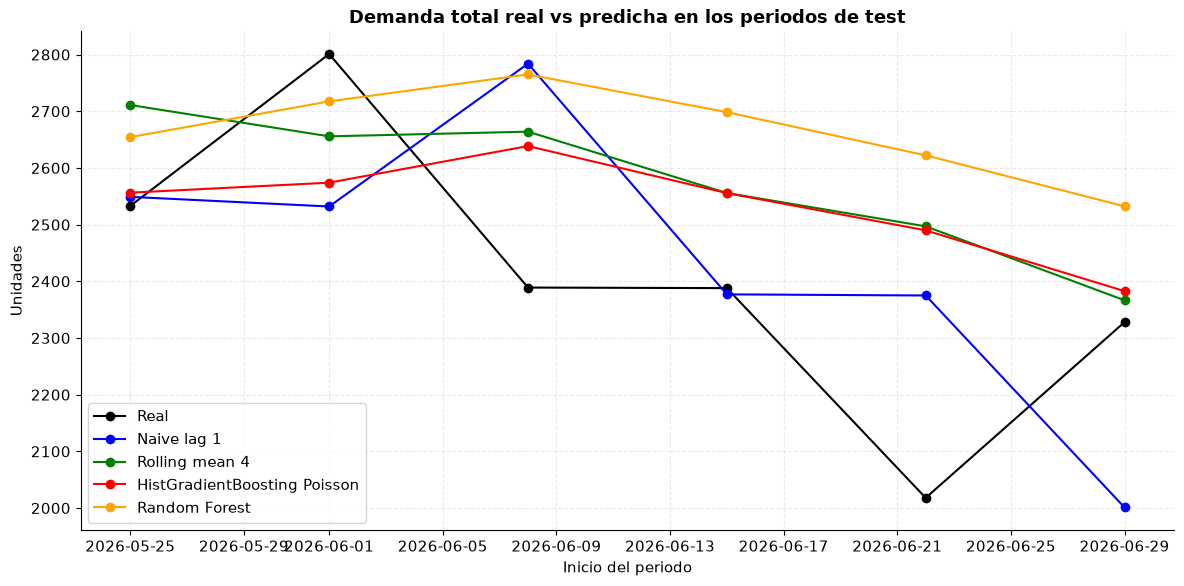

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    period_comparison['report_start'],
    period_comparison['actual_units'],
    marker='o',
    label='Real',
    color='black',
)

for name, column in prediction_columns.items():
    ax.plot(
        period_comparison['report_start'],
        period_comparison[f'{name}_units'],
        marker='o',
        label=name,
        color= ['blue', 'green', 'red', 'orange'][list(prediction_columns.keys()).index(name)]
    )

ax.set_title(
    'Demanda total real vs predicha en los periodos de test'
)
ax.set_xlabel('Inicio del periodo')
ax.set_ylabel('Unidades')
ax.legend()
ax.grid(axis='y', alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'comparacion_demanda_total_test.png',
    dpi=300,
    bbox_inches='tight',
)

plt.show()

## 16. Validación temporal por bloques

Un único test final puede depender demasiado de unas pocas semanas. Por eso se añade una validación de tipo **expanding window**:

- se entrena siempre con semanas anteriores;
- se valida con semanas posteriores;
- nunca se mezclan observaciones de una misma semana entre train y validación.

Esta validación se hace por periodos únicos, no por filas del panel.

In [44]:
def expanding_period_splits(
    frame: pd.DataFrame,
    n_splits: int = 4,
    test_periods_per_split: int = 4,
):
    unique = np.sort(
        frame['period_id'].unique()
    )

    total_test = (
        n_splits
        * test_periods_per_split
    )

    if len(unique) <= total_test + 6:
        raise ValueError(
            'No hay suficientes periodos para '
            'construir los folds solicitados.'
        )

    first_test_position = (
        len(unique)
        - total_test
    )

    for split in range(n_splits):
        test_start = (
            first_test_position
            + split * test_periods_per_split
        )

        test_end = (
            test_start
            + test_periods_per_split
        )

        train_period_ids = unique[:test_start]
        validation_period_ids = unique[
            test_start:test_end
        ]

        yield (
            train_period_ids,
            validation_period_ids,
        )


def cross_validate_panel_model(
    frame: pd.DataFrame,
    pipeline_factory,
    model_name: str,
) -> pd.DataFrame:
    rows = []

    for fold, (
        train_ids,
        validation_ids,
    ) in enumerate(
        expanding_period_splits(
            frame,
            n_splits=N_CV_SPLITS,
            test_periods_per_split=CV_TEST_PERIODS,
        ),
        start=1,
    ):
        train_fold = frame.loc[
            frame['period_id'].isin(train_ids)
        ].copy()

        validation_fold = frame.loc[
            frame['period_id'].isin(validation_ids)
        ].copy()

        model = pipeline_factory()

        model.fit(
            train_fold[feature_columns],
            train_fold['units'],
        )

        validation_fold['prediction'] = np.clip(
            model.predict(
                validation_fold[feature_columns]
            ),
            0,
            None,
        )

        metrics = evaluate_predictions(
            validation_fold,
            'prediction',
            model_name,
        )

        metrics.insert(0, 'fold', fold)
        metrics['train_end'] = (
            train_fold['report_end'].max()
        )
        metrics['validation_start'] = (
            validation_fold['report_start'].min()
        )
        metrics['validation_end'] = (
            validation_fold['report_end'].max()
        )

        rows.append(metrics)

    return pd.concat(
        rows,
        ignore_index=True,
    )

In [45]:
def build_hgb_pipeline():
    preprocessor = ColumnTransformer(
        transformers=[
            (
                'categorical',
                make_one_hot_encoder(dense=True),
                categorical_features,
            ),
            (
                'numeric',
                'passthrough',
                numeric_features,
            ),
        ],
        remainder='drop',
    )

    model = HistGradientBoostingRegressor(
        loss='poisson',
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    )

    return Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', model),
        ]
    )


def build_rf_pipeline():
    preprocessor = ColumnTransformer(
        transformers=[
            (
                'categorical',
                make_one_hot_encoder(dense=False),
                categorical_features,
            ),
            (
                'numeric',
                'passthrough',
                numeric_features,
            ),
        ],
        remainder='drop',
    )

    model = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        max_features=0.7,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    return Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', model),
        ]
    )

In [46]:
cv_hgb = cross_validate_panel_model(
    model_data,
    build_hgb_pipeline,
    'HistGradientBoosting Poisson',
)

cv_rf = cross_validate_panel_model(
    model_data,
    build_rf_pipeline,
    'Random Forest',
)

cv_results = pd.concat(
    [cv_hgb, cv_rf],
    ignore_index=True,
)

display(cv_results)

,fold,model,MAE,RMSE,WAPE,Bias,Top_20_overlap,train_end,validation_start,validation_end
0,1,HistGradientBoosting Poisson,5.312010,10.738048,0.345432,0.005635,0.7750,2026-03-15,2026-03-16,2026-04-12
1,2,HistGradientBoosting Poisson,5.595072,11.241262,0.313026,-0.136318,0.8125,2026-04-12,2026-04-13,2026-05-10
2,3,HistGradientBoosting Poisson,4.857411,8.989176,0.273817,0.007040,0.8500,2026-05-10,2026-05-11,2026-06-07
3,4,HistGradientBoosting Poisson,5.615772,10.649670,0.325017,0.180223,0.8500,2026-06-07,2026-06-08,2026-07-05
4,1,Random Forest,5.377082,10.256972,0.349663,0.031105,0.7875,2026-03-15,2026-03-16,2026-04-12
5,2,Random Forest,5.169821,10.627127,0.289234,-0.109782,0.8250,2026-04-12,2026-04-13,2026-05-10
6,3,Random Forest,4.621760,8.150718,0.260533,0.009936,0.8375,2026-05-10,2026-05-11,2026-06-07
7,4,Random Forest,5.272629,9.581928,0.305157,0.161379,0.8625,2026-06-07,2026-06-08,2026-07-05


In [47]:
cv_summary = (
    cv_results.groupby('model')
    .agg(
        MAE_mean=('MAE', 'mean'),
        MAE_std=('MAE', 'std'),
        WAPE_mean=('WAPE', 'mean'),
        WAPE_std=('WAPE', 'std'),
        Bias_mean=('Bias', 'mean'),
        TopK_mean=(f'Top_{TOP_K}_overlap', 'mean'),
    )
    .sort_values('WAPE_mean')
)

display(cv_summary)

,MAE_mean,MAE_std,WAPE_mean,WAPE_std,Bias_mean,TopK_mean
model,,,,,,
Random Forest,5.110323,0.336520,0.301147,0.037244,0.023160,0.828125
HistGradientBoosting Poisson,5.345066,0.353405,0.314323,0.030136,0.014145,0.821875


## 17. Error por artículo y por departamento

Un WAPE global bueno puede ocultar productos mal modelados.

Se estudian especialmente:

- artículos con más unidades reales;
- artículos con mayor error absoluto;
- departamentos con peor comportamiento.

Esto permite decidir si conviene:

- un único modelo global;
- modelos especializados por familias;
- o reglas distintas para artículos estables y artículos intermitentes.

In [48]:
# Por defecto analizamos el modelo HGB.
# Si Random Forest resulta mejor, basta cambiar esta variable.
SELECTED_PREDICTION = 'pred_hgb_poisson'
SELECTED_MODEL_NAME = 'HistGradientBoosting Poisson'

article_error = (
    test_eval.assign(
        abs_error=lambda d: np.abs(
            d['units']
            - d[SELECTED_PREDICTION]
        )
    )
    .groupby(
        [
            'article_code',
            'article_name',
            'department_name',
        ],
        as_index=False,
    )
    .agg(
        actual_units=('units', 'sum'),
        predicted_units=(
            SELECTED_PREDICTION,
            'sum',
        ),
        MAE=('abs_error', 'mean'),
    )
)

article_error['absolute_total_error'] = np.abs(
    article_error['actual_units']
    - article_error['predicted_units']
)

display(
    article_error.sort_values(
        'actual_units',
        ascending=False,
    ).head(30)
)

,article_code,article_name,department_name,actual_units,predicted_units,MAE,absolute_total_error
18,96,RACIÓN DE PAN,OTROS,2215.0,2347.488601,38.914094,132.488601
29,1637,COPA DE VICTORIA,CERVEZAS,886.0,780.013607,27.249258,105.986393
32,1690,CAFÉ E INFUSIONES,POSTRES,607.0,714.995416,19.048328,107.995416
83,2138,SAM DE GAMBAS,CLASICOS,519.0,457.061695,22.705257,61.938305
146,30001,MENU DEL DIA,MENU DEL DIA,462.0,523.945091,13.882833,61.945091
120,2309,AGUA 70CL,REFRESCOS,417.0,409.172524,8.395392,7.827476
33,1691,CERVEZA VICTORIA,CERVEZAS,414.0,489.768982,21.463588,75.768982
64,1945,EXTRA CROQUETA DE JAMON,EXTRAS,391.0,422.770429,19.746054,31.770429
22,1523,TINTO DE VERANO,CERVEZAS,346.0,316.048088,15.682104,29.951912
68,1974,ZAMBURIÑAS A LA BRASA,CARTA,345.0,375.640322,12.750723,30.640322


In [49]:
department_error = (
    test_eval.assign(
        abs_error=lambda d: np.abs(
            d['units']
            - d[SELECTED_PREDICTION]
        )
    )
    .groupby(
        'department_name',
        as_index=False,
    )
    .agg(
        actual_units=('units', 'sum'),
        predicted_units=(
            SELECTED_PREDICTION,
            'sum',
        ),
        total_absolute_error=(
            'abs_error',
            'sum',
        ),
    )
)

department_error['WAPE'] = (
    department_error['total_absolute_error']
    / department_error['actual_units'].replace(0, np.nan)
)

display(
    department_error.sort_values(
        'actual_units',
        ascending=False,
    )
)

,department_name,actual_units,predicted_units,total_absolute_error,WAPE
10,OTROS,2252.0,2436.261945,289.189607,0.128415
3,CERVEZAS,1983.0,1984.608080,588.149172,0.296596
2,CARTA,1742.0,1917.264212,598.615782,0.343637
12,REFRESCOS,1510.0,1544.734725,382.341541,0.253206
4,CLASICOS,1423.0,1385.585916,307.364130,0.215997
11,POSTRES,1246.0,1421.519776,330.082790,0.264914
14,TAPAS CALIENTES,1048.0,1094.289192,224.324644,0.214050
13,SUGERENCIAS,639.0,627.692599,256.370515,0.401206
15,TAPAS FRIAS,559.0,494.031466,161.739574,0.289337
6,EXTRAS,523.0,573.754309,191.128720,0.365447


## 18. Importancia de variables

Se utiliza importancia por permutación sobre el test.

La interpretación debe ser prudente: las variables temporales y los lags están correlacionados entre sí, de modo que la importancia de una variable aislada no equivale a causalidad.

In [50]:
selected_pipeline = hgb_pipeline

importance = permutation_importance(
    selected_pipeline,
    X_test,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        'feature': feature_columns,
        'importance_mean': importance.importances_mean,
        'importance_std': importance.importances_std,
    }
).sort_values(
    'importance_mean',
    ascending=False,
)

display(importance_df.head(25))

,feature,importance_mean,importance_std
14,units_roll_mean_8,5.492743,0.309827
21,historical_mean_units,2.578541,0.216818
13,units_roll_mean_4,2.184412,0.249471
0,article_code_model,1.381517,0.078379
8,units_lag_1,1.230886,0.145498
10,units_lag_3,0.494819,0.101199
11,units_lag_4,0.324072,0.067820
20,zero_rate_8,0.307405,0.120694
9,units_lag_2,0.282050,0.096436
12,units_roll_mean_2,0.136317,0.089567


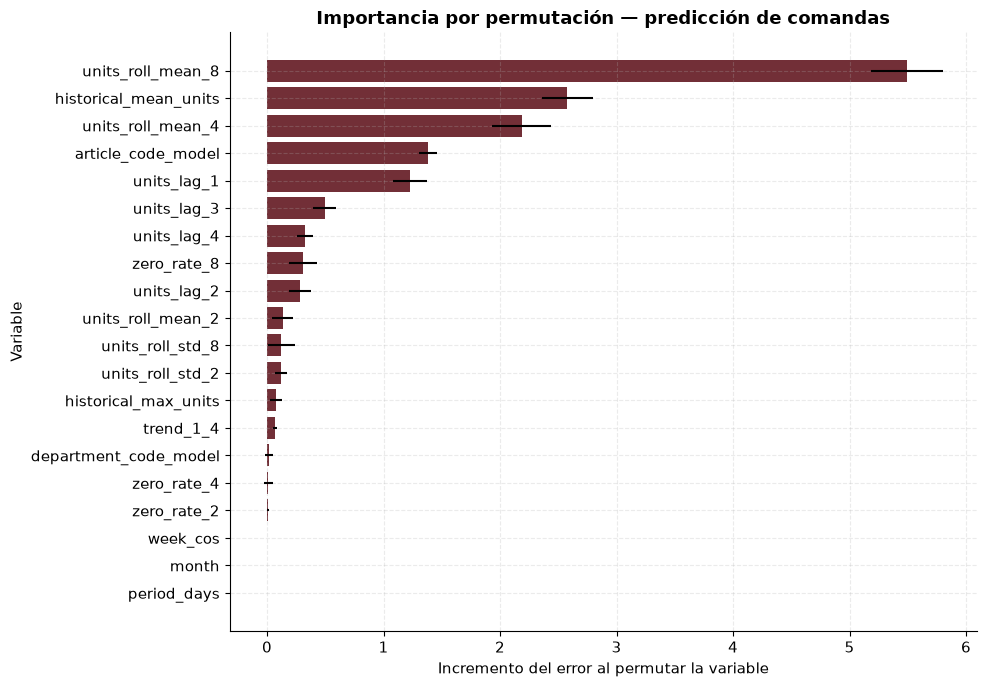

In [51]:
plot_importance = (
    importance_df
    .head(20)
    .sort_values('importance_mean')
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_importance['feature'],
    plot_importance['importance_mean'],
    xerr=plot_importance['importance_std'],
)

ax.set_title(
    'Importancia por permutación — predicción de comandas'
)
ax.set_xlabel(
    'Incremento del error al permutar la variable'
)
ax.set_ylabel('Variable')

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'importancia_variables.png',
    dpi=300,
    bbox_inches='tight',
)

plt.show()

## 19. Predicciones detalladas sobre el periodo de test

Se guarda una tabla para poder inspeccionar qué predijo el modelo para cada artículo y periodo.

In [52]:
test_output = test_eval[
    [
        'report_start',
        'report_end',
        'article_code',
        'article_name',
        'department_code',
        'department_name',
        'units',
        'pred_naive_lag1',
        'pred_rolling_4',
        'pred_hgb_poisson',
        'pred_random_forest',
    ]
].copy()

test_output = test_output.sort_values(
    [
        'report_start',
        SELECTED_PREDICTION,
    ],
    ascending=[True, False],
)

test_output.to_parquet(
    PREDICTIONS_DIR
    / 'comandas_test_predictions.parquet',
    index=False,
)

display(test_output.head(40))

,report_start,report_end,article_code,article_name,department_code,department_name,units,pred_naive_lag1,pred_rolling_4,pred_hgb_poisson,pred_random_forest
733,2026-05-25,2026-05-31,96,RACIÓN DE PAN,15,OTROS,398.0,390.0,433.75,391.830577,390.224419
1159,2026-05-25,2026-05-31,1637,COPA DE VICTORIA,5,CERVEZAS,138.0,118.0,128.50,123.883632,118.935454
1276,2026-05-25,2026-05-31,1690,CAFÉ E INFUSIONES,13,POSTRES,100.0,84.0,121.00,120.884649,123.290005
1315,2026-05-25,2026-05-31,1691,CERVEZA VICTORIA,5,CERVEZAS,103.0,121.0,86.00,95.920804,87.294291
2493,2026-05-25,2026-05-31,1945,EXTRA CROQUETA DE JAMON,22,EXTRAS,56.0,82.0,78.75,78.910090,78.034178
5767,2026-05-25,2026-05-31,30001,MENU DEL DIA,30,MENU DEL DIA,59.0,102.0,69.25,77.904518,70.965460
3237,2026-05-25,2026-05-31,2138,SAM DE GAMBAS,28,CLASICOS,89.0,73.0,81.25,69.530483,76.148720
4667,2026-05-25,2026-05-31,2309,AGUA 70CL,4,REFRESCOS,71.0,65.0,77.25,67.857151,73.244110
72,2026-05-25,2026-05-31,2,RAVIOLI DE RABO DE TERNERA,28,CLASICOS,70.0,46.0,61.75,63.019497,68.024092
616,2026-05-25,2026-05-31,48,AGUA CRISTAL,4,REFRESCOS,60.0,55.0,46.00,55.501072,53.675373


## 20. Forecast del siguiente periodo

### Qué puede hacerse con el histórico actual

El modelo principal está pensado para producir una previsión **una semana hacia delante**.

Para un forecast futuro completamente operativo se necesitan:

- lags de ventas: disponibles;
- calendario: disponible;
- festivos/eventos: disponibles si la base incluye las fechas futuras;
- meteorología: debe provenir de una previsión, no del histórico real;
- predicciones de clientes/ventas/no-show: podrán incorporarse cuando los compañeros generen sus outputs.

La función siguiente construye una fila futura por artículo utilizando exclusivamente la información histórica disponible. El contexto externo futuro se puede incorporar después.

In [53]:
def build_next_period_panel(
    full_panel: pd.DataFrame,
    period_length_days: int = 7,
) -> pd.DataFrame:
    history = full_panel.copy().sort_values(
        ['article_code', 'period_id']
    )

    last_period_id = int(
        history['period_id'].max()
    )

    last_report_end = pd.to_datetime(
        history['report_end'].max()
    )

    next_start = (
        last_report_end
        + pd.Timedelta(days=1)
    )

    next_end = (
        next_start
        + pd.Timedelta(
            days=period_length_days - 1
        )
    )

    latest_meta = (
        history.sort_values('period_id')
        .groupby('article_code', as_index=False)
        .tail(1)
        [
            [
                'article_code',
                'article_name',
                'department_code',
                'department_name',
            ]
        ]
    )

    future = latest_meta.copy()
    future['report_start'] = next_start
    future['report_end'] = next_end
    future['period_id'] = last_period_id + 1
    future['units'] = np.nan
    future['amount'] = np.nan

    combined = pd.concat(
        [
            history[
                [
                    'report_start',
                    'report_end',
                    'period_id',
                    'article_code',
                    'article_name',
                    'department_code',
                    'department_name',
                    'units',
                    'amount',
                ]
            ],
            future,
        ],
        ignore_index=True,
    )

    combined_features = add_demand_features(
        combined
    )

    future_features = combined_features.loc[
        combined_features['period_id']
        == last_period_id + 1
    ].copy()

    future_features[
        'article_code_model'
    ] = future_features[
        'article_code'
    ].astype('string')

    future_features[
        'department_code_model'
    ] = future_features[
        'department_code'
    ].astype('string')

    return future_features


future_panel = build_next_period_panel(
    panel,
)

print(
    'Periodo futuro:',
    future_panel['report_start'].iloc[0].date(),
    '→',
    future_panel['report_end'].iloc[0].date(),
)

display(future_panel.head())

Periodo futuro: 2026-07-06 → 2026-07-12


,report_start,report_end,period_id,article_code,article_name,department_code,department_name,units,amount,units_lag_1,units_lag_2,units_lag_3,units_lag_4,units_roll_mean_2,units_roll_std_2,zero_rate_2,units_roll_mean_4,units_roll_std_4,zero_rate_4,units_roll_mean_8,units_roll_std_8,zero_rate_8,historical_mean_units,historical_max_units,trend_1_4,period_days,month,quarter,week_of_year,week_sin,week_cos,article_code_model,department_code_model
39,2026-07-06,2026-07-12,39,1,NUESTRAS CROQUETAS DE JAMON,28,CLASICOS,NaN,NaN,28.0,28.0,32.0,31.0,28.0,0.000000,0.0,29.75,2.061553,0.0,31.625,4.596194,0.0,27.025641,47.0,-3.0,7,7,3,28,-0.239316,-0.970942,1,28
79,2026-07-06,2026-07-12,39,2,RAVIOLI DE RABO DE TERNERA,28,CLASICOS,NaN,NaN,52.0,48.0,46.0,49.0,50.0,2.828427,0.0,48.75,2.500000,0.0,54.875,13.206465,0.0,60.974359,110.0,3.0,7,7,3,28,-0.239316,-0.970942,2,28
119,2026-07-06,2026-07-12,39,3,NUESTRAS PATATAS BRAVAS,28,CLASICOS,NaN,NaN,16.0,14.0,16.0,15.0,15.0,1.414214,0.0,15.25,0.957427,0.0,15.875,3.681518,0.0,17.512821,27.0,1.0,7,7,3,28,-0.239316,-0.970942,3,28
159,2026-07-06,2026-07-12,39,10,KIMUCHI DE MARISCOS,28,CLASICOS,NaN,NaN,25.0,25.0,43.0,23.0,25.0,0.000000,0.0,29.00,9.380832,0.0,28.625,8.016724,0.0,28.333333,54.0,2.0,7,7,3,28,-0.239316,-0.970942,10,28
199,2026-07-06,2026-07-12,39,11,BOMBONES DE FOIE,2,TAPAS FRIAS,NaN,NaN,13.0,8.0,14.0,5.0,10.5,3.535534,0.0,10.00,4.242641,0.0,12.125,3.681518,0.0,12.666667,21.0,8.0,7,7,3,28,-0.239316,-0.970942,11,2


### Contexto futuro

Las columnas de calendario básicas se calculan directamente.

Si el modelo final utiliza festivos/eventos, conviene crear una función específica que agregue `festivos_silver` y `eventos_silver` para el intervalo futuro.

Para evitar rellenar artificialmente información desconocida, esta primera versión del forecast final utiliza un **modelo deployable basado en historia del artículo + calendario básico**.

Por tanto se reentrena un modelo final con un subconjunto de variables que siempre estarán disponibles.

In [54]:
deployable_numeric_features = [
    column
    for column in base_numeric_features
    if column in model_data.columns
]

deployable_features = (
    categorical_features
    + deployable_numeric_features
)

deployable_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            make_one_hot_encoder(dense=True),
            categorical_features,
        ),
        (
            'numeric',
            'passthrough',
            deployable_numeric_features,
        ),
    ],
    remainder='drop',
)

deployable_model = HistGradientBoostingRegressor(
    loss='poisson',
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=RANDOM_STATE,
)

deployable_pipeline = Pipeline(
    steps=[
        ('preprocess', deployable_preprocessor),
        ('model', deployable_model),
    ]
)

deployable_pipeline.fit(
    model_data[deployable_features],
    model_data['units'],
)

future_panel['predicted_units'] = np.clip(
    deployable_pipeline.predict(
        future_panel[deployable_features]
    ),
    0,
    None,
)

future_panel['predicted_units_rounded'] = np.rint(
    future_panel['predicted_units']
).astype(int)

future_forecast = (
    future_panel[
        [
            'report_start',
            'report_end',
            'article_code',
            'article_name',
            'department_code',
            'department_name',
            'predicted_units',
            'predicted_units_rounded',
        ]
    ]
    .sort_values(
        'predicted_units',
        ascending=False,
    )
    .reset_index(drop=True)
)

future_forecast.to_parquet(
    PREDICTIONS_DIR
    / 'comandas_next_period_forecast.parquet',
    index=False,
)

display(future_forecast.head(40))

,report_start,report_end,article_code,article_name,department_code,department_name,predicted_units,predicted_units_rounded
0,2026-07-06,2026-07-12,96,RACIÓN DE PAN,15,OTROS,364.939027,365
1,2026-07-06,2026-07-12,1637,COPA DE VICTORIA,5,CERVEZAS,142.509489,143
2,2026-07-06,2026-07-12,1690,CAFÉ E INFUSIONES,13,POSTRES,93.376863,93
3,2026-07-06,2026-07-12,2138,SAM DE GAMBAS,28,CLASICOS,75.269622,75
4,2026-07-06,2026-07-12,30001,MENU DEL DIA,30,MENU DEL DIA,64.931434,65
5,2026-07-06,2026-07-12,2309,AGUA 70CL,4,REFRESCOS,62.337380,62
6,2026-07-06,2026-07-12,1945,EXTRA CROQUETA DE JAMON,22,EXTRAS,57.141313,57
7,2026-07-06,2026-07-12,2,RAVIOLI DE RABO DE TERNERA,28,CLASICOS,50.254792,50
8,2026-07-06,2026-07-12,2381,PAN BAO DE CARRILLERA DE CERDO,1,TAPAS CALIENTES,48.429285,48
9,2026-07-06,2026-07-12,1691,CERVEZA VICTORIA,5,CERVEZAS,45.671148,46


## 21. Artículos de cola: estrategia de respaldo

El modelo principal se concentra en artículos con suficiente histórico.

Para artículos raros, nuevos o muy intermitentes, una estrategia prudente es utilizar una predicción simple:

- media de las últimas semanas;
- último valor observado;
- o cero hasta disponer de suficiente historial.

No conviene forzar una predicción compleja para un artículo que solo ha aparecido una o dos veces.

En una versión de producción, la salida final debería combinar:

> modelo global para catálogo principal + regla de respaldo para la cola.

In [55]:
tail_articles = article_summary.loc[
    ~article_summary['is_core']
].copy()

display(
    tail_articles.sort_values(
        'total_units',
        ascending=False,
    ).head(30)
)

,article_code,article_name,department_code,positive_periods,total_units,total_amount,is_core
153,2232,MAHOU,5,6,118.0,400.72759,False
226,2374,CROQUETA DE CECINA,14,5,111.0,161.45451,False
54,1751,KELLER,5,5,65.0,224.54558,False
254,34010,RABAS DE ANCHOA,14,3,63.0,378.18178,False
261,34017,"LINGOTE ""LA ROCA""",13,7,59.0,421.81829,False
255,34011,CROQUETA DE CHIPIRONES EN SU TINTA,14,4,56.0,81.45454,False
90,2023,RAIMAT ALBARIÑO,8,4,27.0,100.63630,False
139,2210,CAPUCCINO,13,13,19.0,60.45448,False
157,2246,MEJILLONES A LA BRASA CON SALSA THAI,14,7,18.0,237.27276,False
137,2204,CARAJILLO,13,13,18.0,73.63640,False


# 22. Platos que se piden juntos — análisis de cesta

## ¿Tiene sentido?

Sí, pero es un problema distinto al forecasting. La predicción anterior responde a **¿cuántas unidades de cada artículo esperamos vender?**

El análisis de cesta responde:

> **¿qué artículos tienden a aparecer juntos en el mismo ticket?**

Para estudiar coocurrencia necesitamos datos a nivel:

`ticket_id × artículo`

Los informes semanales agregados **no permiten reconstruir qué platos aparecieron juntos**.

### Situación actual

Los PDFs contienen líneas de producto por ticket, pero solo existen 72 documentos. Esto permite hacer una exploración o prueba de concepto, pero no sería prudente presentar reglas de asociación de 72 tickets como un patrón robusto de todo el restaurante.

La solución correcta sería guardar, durante el procesamiento de PDFs o desde una exportación detallada del TPV, una tabla como:

| ticket_id | fecha | article_name | quantity | unit_price | amount |
|---|---|---:|---:|---:|---:|

y crear posteriormente:

`factura_items_silver.parquet`

La sección siguiente se ejecuta automáticamente si ese fichero existe.

In [ ]:
BASKET_PATH = (
    SILVER_DIR
    / 'factura_items_silver.parquet'
)

if BASKET_PATH.exists():
    basket_items = pd.read_parquet(
        BASKET_PATH
    )

    print(
        'Dataset de líneas de ticket encontrado:',
        basket_items.shape,
    )

    display(basket_items.head())

else:
    basket_items = None

    print(
        'No existe factura_items_silver.parquet. '
        'Se omite el análisis de cesta.'
    )

### Métricas de asociación

Para una regla `A → B`:

- **support(A,B)**: proporción de tickets donde aparecen A y B.
- **confidence(A→B)**: entre los tickets que contienen A, proporción que también contiene B.
- **lift(A→B)**: compara esa probabilidad con la frecuencia general de B.

Interpretación orientativa:

- `lift > 1`: aparecen juntos más de lo esperado si fueran independientes;
- `lift ≈ 1`: no hay asociación especial;
- `lift < 1`: aparecen juntos menos de lo esperado.

Con una muestra pequeña deben exigirse además **conteos mínimos**, porque un lift alto basado en dos tickets no es una evidencia útil.

In [ ]:
def association_rules_from_tickets(
    dataframe: pd.DataFrame,
    ticket_column: str = 'ticket_id',
    item_column: str = 'article_name',
    min_pair_count: int = 3,
    min_support: float = 0.02,
) -> pd.DataFrame:
    data = dataframe[
        [ticket_column, item_column]
    ].dropna().drop_duplicates()

    baskets = (
        data.groupby(ticket_column)[item_column]
        .apply(
            lambda values: sorted(
                set(values.astype(str))
            )
        )
    )

    n_tickets = len(baskets)

    if n_tickets == 0:
        return pd.DataFrame()

    item_counts = (
        data.groupby(item_column)[ticket_column]
        .nunique()
        .to_dict()
    )

    pair_counts = {}

    for items in baskets:
        for item_a, item_b in combinations(
            items,
            2,
        ):
            pair = tuple(
                sorted(
                    [item_a, item_b]
                )
            )

            pair_counts[pair] = (
                pair_counts.get(pair, 0)
                + 1
            )

    rows = []

    for (item_a, item_b), count in pair_counts.items():
        support_ab = count / n_tickets

        if (
            count < min_pair_count
            or support_ab < min_support
        ):
            continue

        support_a = (
            item_counts[item_a]
            / n_tickets
        )

        support_b = (
            item_counts[item_b]
            / n_tickets
        )

        confidence_a_b = (
            support_ab
            / support_a
        )

        confidence_b_a = (
            support_ab
            / support_b
        )

        lift = (
            support_ab
            / (support_a * support_b)
        )

        rows.append(
            {
                'item_a': item_a,
                'item_b': item_b,
                'pair_count': count,
                'support': support_ab,
                'confidence_a_to_b': confidence_a_b,
                'confidence_b_to_a': confidence_b_a,
                'lift': lift,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values(
            ['lift', 'pair_count'],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )


if basket_items is not None:
    association_rules = (
        association_rules_from_tickets(
            basket_items,
            ticket_column='ticket_id',
            item_column='article_name',
            min_pair_count=3,
            min_support=0.02,
        )
    )

    display(
        association_rules.head(30)
    )

## 23. Cómo usar la coocurrencia dentro del proyecto

El análisis de cesta puede aportar valor de varias maneras:

1. **Interpretación comercial**  
   Detectar combinaciones habituales de platos.

2. **Planificación conjunta**  
   Si dos artículos con ingredientes diferentes aparecen juntos muy a menudo, sus previsiones pueden revisarse conjuntamente.

3. **Feature engineering futuro**  
   Con suficientes tickets históricos, podrían crearse variables como demanda reciente del "plato compañero".

4. **Recomendación / cross-selling**  
   Es una aplicación distinta del objetivo principal del TFM, pero técnicamente posible.

### Lo que no se recomienda en esta fase

No ajustar la predicción semanal multiplicando directamente por reglas de asociación obtenidas de solo 72 tickets.

La coocurrencia debe considerarse un **módulo complementario** hasta disponer de una muestra de tickets mucho mayor.

# 24. Conclusiones metodológicas

Con los datos disponibles, el planteamiento más defendible para el TFM es:

### Modelo principal

**Forecast global artículo-periodo**

- target: unidades semanales por artículo;
- un único modelo aprende de todos los artículos;
- usa identidad del artículo, departamento, demanda histórica y calendario;
- validación estrictamente temporal;
- comparación frente a baselines;
- salida: ranking y unidades esperadas por artículo.

### Integración con el resto del TFM

Cuando estén disponibles las predicciones de los compañeros, el modelo puede incorporar:

- clientes previstos;
- ventas previstas;
- no-shows previstos.

Es importante incorporar **predicciones**, no resultados reales del periodo futuro.

### Coocurrencia

Se mantiene como línea complementaria mediante análisis de cesta.  
Para convertirla en una parte robusta del sistema hace falta un histórico mucho mayor de líneas de ticket.

### Paso posterior: ingredientes

Para traducir la previsión de comandas a ingredientes hará falta una nueva tabla de recetas/BOM:

| article_code | ingredient | quantity_per_unit | unit |
|---|---|---:|---|

Entonces:

`unidades previstas de plato × cantidad de ingrediente por plato`

permitirá obtener las necesidades previstas de materia prima por periodo.

## 25. Próximos pasos

1. Ejecutar el notebook completo y revisar la auditoría inicial.
2. Ajustar los umbrales del catálogo modelable si fuera necesario.
3. Comparar baselines, HGB Poisson y Random Forest.
4. Revisar errores por artículo y departamento.
5. Elegir el modelo final en función de validación temporal, no de un único split.
6. Integrar las predicciones de clientes/ventas/no-show cuando estén disponibles.
7. Solicitar, si es posible, una exportación de líneas de ticket del TPV.
8. Crear `factura_items_silver.parquet` para estudiar coocurrencia de forma robusta.
9. Crear una tabla de recetas para convertir demanda de platos en ingredientes.